## 04 — Star centroid and WCS quality checks

Same setup as 03 (imports → solve → full-field display), then:
- **3×3 cutout grid**: top-9 brightest astrometry-confirmed sources zoomed in at native pixel scale, each with a WCS sky-coordinate grid and a lime circle marking the DAOStarFinder centroid.
- **Catalog lookup**: Simbad query at each WCS-derived sky position to check how accurately the plate solution places known stars.

In [6]:
import sys
import os
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter

sys.path.insert(0, os.path.abspath('..'))

from extractor.platesolve import platesolve
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u

data_dir = Path('../data')
fits_files = sorted(data_dir.glob('*.fit')) + sorted(data_dir.glob('*.fits'))
if not fits_files:
    raise FileNotFoundError(f'No FITS files found in {data_dir.resolve()}')

image_path = fits_files[0]
print(f'Using: {image_path}')

with afits.open(image_path) as hdul:
    image = hdul[0].data.astype(float)

Using: ..\data\fuji6_asi178_100_15s.fit


In [7]:
result = platesolve(image_path, write=False, verbose=True)

Logged in to nova.astrometry.net


Task was destroyed but it is pending!
task: <Task pending name='Task-80' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\bassd\miniconda3\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-81' coro=<Kernel.shell_main() running at C:\Users\bassd\miniconda3\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\bassd\miniconda3\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\bassd\miniconda3\Lib\site-packages\scipy\ndimage\_measurements.py:308: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return _nd_image.find_objects(input, max_label)
Task was destroyed but it is pending!
task: <Task pending name='Task-81' coro=<Kernel.shell_main() running at C:\Users\bassd\miniconda3\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Detected 255 sources for submission.
Source list uploaded (submission 14944820)
Waiting for job assignment. job 15780752
Solving. solved!
WCS header fetched.


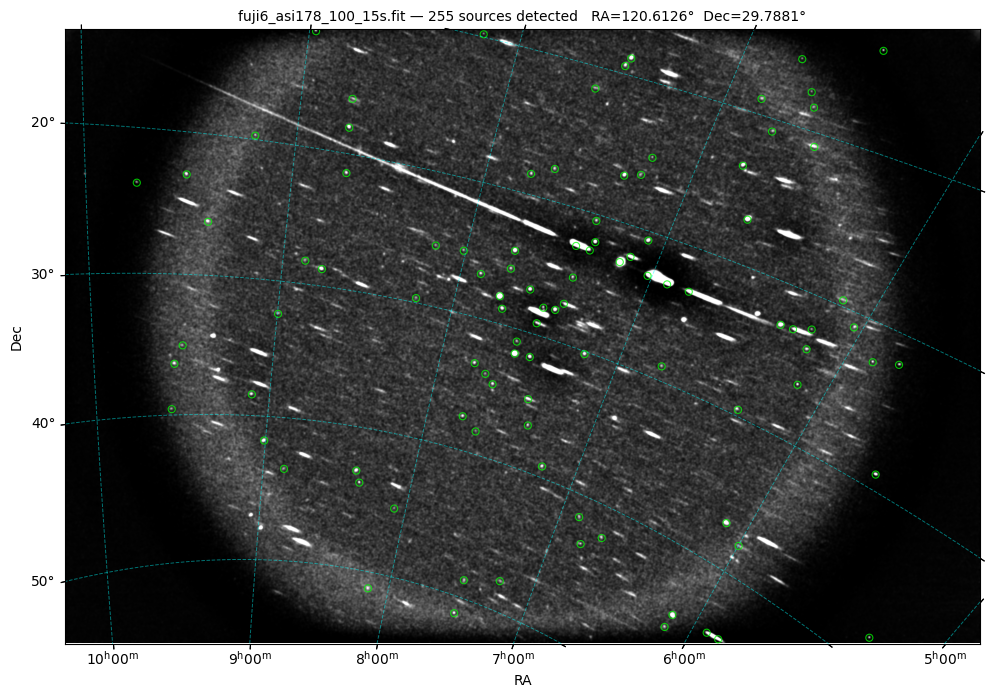

In [8]:
# Full-field display — stripe-style preprocessing (mirrors tele-img-sim _show_final_result)
if result is None:
    print('Solve failed.')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs = WCS(result.header)

    bg = gaussian_filter(image.astype(np.float32), sigma=50.0)
    processed = np.clip(image.astype(np.float32) - bg, 0.0, None)
    processed = gaussian_filter(processed, sigma=2.5)

    finite = processed[np.isfinite(processed)]
    lo, hi = np.percentile(finite, [0.5, 99.5])
    disp = np.arcsinh(np.clip(processed, lo, hi))

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': wcs})
    ax.imshow(disp, origin='lower', cmap='gray',
              vmin=np.arcsinh(lo), vmax=np.arcsinh(hi))

    ax.coords.grid(True, color='cyan', alpha=0.45, linestyle='--', linewidth=0.7)
    ax.coords['ra'].set_axislabel('RA')
    ax.coords['dec'].set_axislabel('Dec')

    n_show = min(100, len(result.detected_x))
    for x, y in zip(result.detected_x[:n_show], result.detected_y[:n_show]):
        ax.add_patch(Circle((x, y), radius=12,
                             edgecolor='lime', facecolor='none',
                             linewidth=0.8, alpha=0.75))

    ra  = result.header.get('CRVAL1', float('nan'))
    dec = result.header.get('CRVAL2', float('nan'))
    n_src = len(result.detected_x)
    ax.set_title(
        f"{image_path.name} — {n_src} sources detected   RA={ra:.4f}°  Dec={dec:.4f}°",
        fontsize=10,
    )
    ax.set_xlim(-0.5, image.shape[1] - 0.5)
    ax.set_ylim(-0.5, image.shape[0] - 0.5)
    plt.tight_layout()
    plt.show()

## Star centroid quality checks

Nine of the brightest astrometry-confirmed sources zoomed in at native pixel resolution.  
The **lime circle** (r = 5 px ≈ 1.7× FWHM) marks the DAOStarFinder centroid.  
Well-centroided stars should sit cleanly inside the circle with the bright PSF peak at its centre.  
The cyan grid lines are the WCS sky-coordinate mesh at this cutout scale.

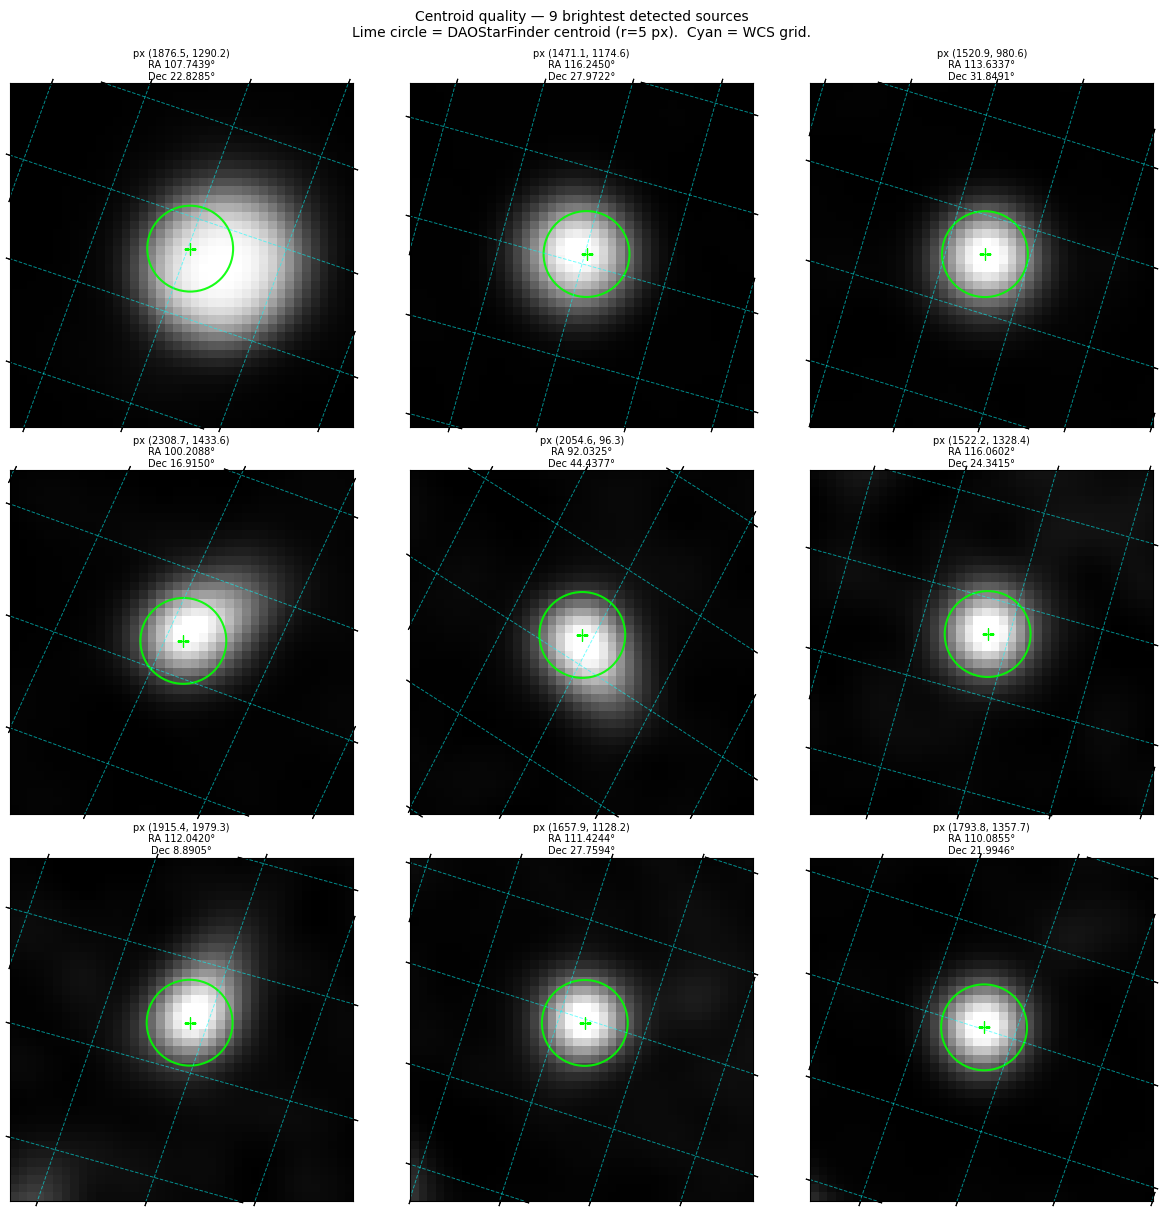

star_x / star_y set with 9 sources — available for catalog cell.


In [9]:
assert result is not None, 'Run the platesolve cell first.'

CUTOUT_SIZE = 40    # pixels per side of each thumbnail
APERTURE_R  = 5.0   # centroid-marker radius in pixels (~1.7× FWHM)
MARGIN      = CUTOUT_SIZE // 2 + 5  # minimum distance from image edge

h, w = image.shape

# Prefer detected sources that were confirmed by astrometry.net (matched);
# fall back to the brightest detected if fewer than 9 were matched.
# detected_x/y are flux-sorted brightest-first from extract_stars.
if len(result.matched_x) >= 9:
    det_xy  = np.column_stack([result.detected_x, result.detected_y])
    mat_xy  = np.column_stack([result.matched_x,  result.matched_y])
    # Vectorised nearest-neighbour: (N_det, N_mat, 2) → (N_det,) min dist
    diffs    = det_xy[:, np.newaxis, :] - mat_xy[np.newaxis, :, :]
    min_dist = np.sqrt((diffs**2).sum(axis=2)).min(axis=1)
    cand_x = result.detected_x[min_dist < 5.0]
    cand_y = result.detected_y[min_dist < 5.0]
    source_label = 'astrometry-confirmed'
else:
    cand_x = result.detected_x.copy()
    cand_y = result.detected_y.copy()
    source_label = 'brightest detected'

# Remove stars whose cutout would clip the image boundary
in_bounds = (
    (cand_x >= MARGIN) & (cand_x <= w - MARGIN) &
    (cand_y >= MARGIN) & (cand_y <= h - MARGIN)
)
cand_x, cand_y = cand_x[in_bounds], cand_y[in_bounds]

n_stars = min(9, len(cand_x))
if n_stars == 0:
    print('No suitable sources found after edge filtering.')
else:
    star_x = cand_x[:n_stars]
    star_y = cand_y[:n_stars]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs_cut = WCS(result.header)

    # Same preprocessing as the full-field display
    _bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
    _proc = np.clip(image.astype(np.float32) - _bg, 0.0, None)
    _proc = gaussian_filter(_proc, sigma=2.5)

    fig = plt.figure(figsize=(12, 12), constrained_layout=True)
    fig.suptitle(
        f'Centroid quality — {n_stars} {source_label} sources\n'
        'Lime circle = DAOStarFinder centroid (r=5 px).  Cyan = WCS grid.',
        fontsize=10,
    )

    for i, (x, y) in enumerate(zip(star_x, star_y)):
        ix, iy = int(round(x)), int(round(y))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            cutout = Cutout2D(_proc, position=(ix, iy), size=CUTOUT_SIZE,
                              wcs=wcs_cut, mode='partial', fill_value=0.0)

        # Detected centroid in cutout pixel coordinates
        x_cut = x - cutout.origin_original[0]
        y_cut = y - cutout.origin_original[1]

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            sky = wcs_cut.pixel_to_world(x, y)

        # Per-cutout stretch
        finite_c = cutout.data[np.isfinite(cutout.data) & (cutout.data > 0)]
        c_lo = float(np.percentile(finite_c, 1.0))  if finite_c.size else 0.0
        c_hi = float(np.percentile(finite_c, 99.5)) if finite_c.size else 1.0
        c_disp = np.arcsinh(np.clip(cutout.data, c_lo, c_hi))

        ax = fig.add_subplot(3, 3, i + 1, projection=cutout.wcs)
        ax.imshow(c_disp, origin='lower', cmap='gray',
                  vmin=np.arcsinh(c_lo), vmax=np.arcsinh(c_hi))

        ax.coords.grid(True, color='cyan', alpha=0.55, linestyle='--', linewidth=0.7)
        for coord_name in ('ra', 'dec'):
            ax.coords[coord_name].set_ticklabel_visible(False)
            ax.coords[coord_name].set_axislabel('')

        ax.add_patch(Circle(
            (x_cut, y_cut), radius=APERTURE_R,
            edgecolor='lime', facecolor='none', linewidth=1.5, alpha=0.9,
        ))
        # Cross-hair at exact sub-pixel centroid
        ax.plot(x_cut, y_cut, '+', color='lime', markersize=8, markeredgewidth=1.0)

        ax.set_title(
            f'px ({x:.1f}, {y:.1f})\nRA {sky.ra.deg:.4f}\u00b0\nDec {sky.dec.deg:.4f}\u00b0',
            fontsize=7, pad=3,
        )

    plt.show()
    print(f'star_x / star_y set with {n_stars} sources — available for catalog cell.')